<a href="https://colab.research.google.com/github/tnghks023/ml-study/blob/master/feature_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Feature Engineering 성능 비교


In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

### 데이터 불러오기, 전처리, Feature Engineering

In [ ]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

# 결측치 처리
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Cabin 삭제
df = df.drop(columns=["Cabin"])

# Sex 숫자 변환
df["Sex"] = df["Sex"].map({
    "male": 0,
    "female": 1
})

# Title 추출
df["Title"] = df["Name"].str.extract(" ([A-Za-z]+)\.")

# 희귀 Title 정리
rare_titles = [
    "Lady", "Countess", "Capt", "Col", "Don",
    "Dr", "Major", "Rev", "Sir", "Jonkheer", "Dona"
]

df["Title"] = df["Title"].replace(rare_titles, "Rare")

# 비슷한 Title 통합
df["Title"] = df["Title"].replace("Mlle", "Miss")
df["Title"] = df["Title"].replace("Ms", "Miss")
df["Title"] = df["Title"].replace("Mme", "Mrs")

# Title 숫자 변환
title_encoder = LabelEncoder()
df["Title"] = title_encoder.fit_transform(df["Title"])

# FamilySize 생성
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

# IsAlone 생성
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

df.head()

<>:19: SyntaxWarning: invalid escape sequence '\.'
<>:19: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_1861/2872124750.py:19: SyntaxWarning: invalid escape sequence '\.'
  df["Title"] = df["Name"].str.extract(" ([A-Za-z]+)\.")


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title,FamilySize,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,S,2,2,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C,3,2,0
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,S,1,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,S,3,2,0
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,S,2,1,1


### 함수 만들기

1. Train/Test 분리
2. Logistic Regression 학습
3. Random Forest 학습
4. Accuracy, F1-score 저장

In [ ]:
def run_experiment(feature_list, experiment_name):
    X = df[feature_list].copy()
    y = df["Survived"]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    # Logistic Regression: Scaling 적용
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    log_model = LogisticRegression(max_iter=1000)
    log_model.fit(X_train_scaled, y_train)

    pred_log = log_model.predict(X_test_scaled)

    # Random Forest: Scaling 없이 학습
    rf_model = RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )

    rf_model.fit(X_train, y_train)

    pred_rf = rf_model.predict(X_test)

    # 결과 저장
    result = {
        "Experiment": experiment_name,
        "Features": ", ".join(feature_list),
        "Logistic Accuracy": accuracy_score(y_test, pred_log),
        "Logistic F1": f1_score(y_test, pred_log),
        "RandomForest Accuracy": accuracy_score(y_test, pred_rf),
        "RandomForest F1": f1_score(y_test, pred_rf)
    }

    return result

### Feature 조합

In [ ]:
baseline_features = [
    "Pclass",
    "Sex",
    "Age",
    "Fare",
    "SibSp",
    "Parch"
]

title_features = [
    "Pclass",
    "Sex",
    "Age",
    "Fare",
    "SibSp",
    "Parch",
    "Title"
]

family_features = [
    "Pclass",
    "Sex",
    "Age",
    "Fare",
    "SibSp",
    "Parch",
    "Title",
    "FamilySize"
]

alone_features = [
    "Pclass",
    "Sex",
    "Age",
    "Fare",
    "SibSp",
    "Parch",
    "Title",
    "FamilySize",
    "IsAlone"
]

In [ ]:
results = []

results.append(run_experiment(baseline_features, "Baseline"))
results.append(run_experiment(title_features, "+ Title"))
results.append(run_experiment(family_features, "+ Title + FamilySize"))
results.append(run_experiment(alone_features, "+ Title + FamilySize + IsAlone"))

result_df = pd.DataFrame(results)

result_df

,Experiment,Features,Logistic Accuracy,Logistic F1,RandomForest Accuracy,RandomForest F1
0,Baseline,"Pclass, Sex, Age, Fare, SibSp, Parch",0.798883,0.746479,0.798883,0.753425
1,+ Title,"Pclass, Sex, Age, Fare, SibSp, Parch, Title",0.810056,0.757143,0.815642,0.781457
2,+ Title + FamilySize,"Pclass, Sex, Age, Fare, SibSp, Parch, Title, F...",0.810056,0.757143,0.821229,0.789474
3,+ Title + FamilySize + IsAlone,"Pclass, Sex, Age, Fare, SibSp, Parch, Title, F...",0.804469,0.751773,0.821229,0.783784


### 정렬

In [ ]:
result_df.sort_values(
    by="Logistic Accuracy",
    ascending=False
)

,Experiment,Features,Logistic Accuracy,Logistic F1,RandomForest Accuracy,RandomForest F1
1,+ Title,"Pclass, Sex, Age, Fare, SibSp, Parch, Title",0.810056,0.757143,0.815642,0.781457
2,+ Title + FamilySize,"Pclass, Sex, Age, Fare, SibSp, Parch, Title, F...",0.810056,0.757143,0.821229,0.789474
3,+ Title + FamilySize + IsAlone,"Pclass, Sex, Age, Fare, SibSp, Parch, Title, F...",0.804469,0.751773,0.821229,0.783784
0,Baseline,"Pclass, Sex, Age, Fare, SibSp, Parch",0.798883,0.746479,0.798883,0.753425


### 정확도 그래프 비교

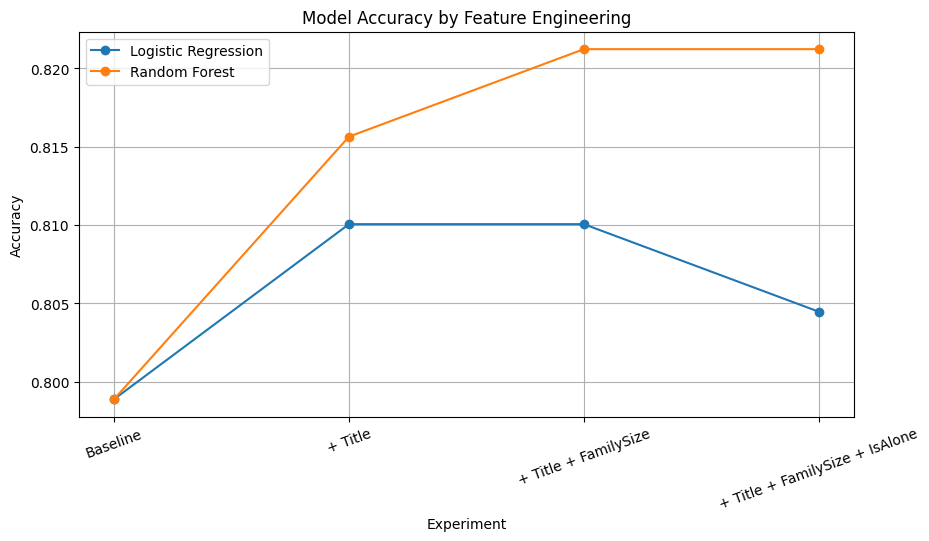

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(result_df["Experiment"], result_df["Logistic Accuracy"], marker="o", label="Logistic Regression")
plt.plot(result_df["Experiment"], result_df["RandomForest Accuracy"], marker="o", label="Random Forest")

plt.xlabel("Experiment")
plt.ylabel("Accuracy")
plt.title("Model Accuracy by Feature Engineering")
plt.xticks(rotation=20)
plt.legend()
plt.grid(True)

plt.show()

### F1-score 그래프 비교

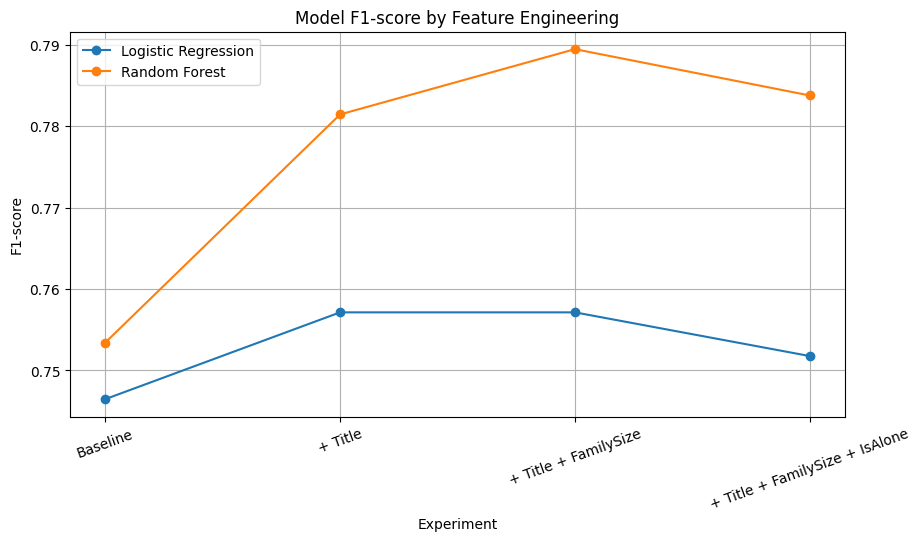

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(result_df["Experiment"], result_df["Logistic F1"], marker="o", label="Logistic Regression")
plt.plot(result_df["Experiment"], result_df["RandomForest F1"], marker="o", label="Random Forest")

plt.xlabel("Experiment")
plt.ylabel("F1-score")
plt.title("Model F1-score by Feature Engineering")
plt.xticks(rotation=20)
plt.legend()
plt.grid(True)

plt.show()

### Feature Engineering 실험 결과
* Name에서 추출한 Title은 두 모델 모두에서 성능 향상에 기여했다.

* FamilySize는 Random Forest에서 추가적인 성능 향상을 보였지만, IsAlone은 FamilySize와 정보가 중복되어 성능 개선 효과가 크지 않았다.

* 따라서 현재 실험에서는 Random Forest + Title + FamilySize 조합이 가장 좋은 성능을 보였다.

### Feature가 많다고 좋은 게 아닌 이유

1. 중복 정보가 생길 수 있음

- 오히려 복잡도만 늘 수 있음

2. 노이즈가 들어갈 수 있음

3. 과적합 위험이 커짐

- 모델이 훈련 데이터를 더 세세하게 외울 수 있음

4. 해석이 어려워짐

- 모델이 예측 이류를 설명하기 어려워짐.
